In [59]:
import pymc as pm
import pymc_bart as pmb
import numpy as np
import pandas as pd
import arviz as az
import matplotlib.pyplot as plt
from numpy.linalg import inv
import pytensor as pt
import arviz as az
from sklearn.linear_model import LogisticRegression, BayesianRidge, LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor
from scipy.stats import gamma
import seaborn as sns
import shap
import itertools
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score, cross_val_predict
import xgboost as xgb

In [68]:
"""To try:"""

# with pm.Model() as model:
#     # Prior distributions for the unknown parameters

#     alpha = pm.Normal('alpha', mu=0, sigma=10)
#     # Priors for the binary variables
#     offline_campaign_prior = pm.Bernoulli('MISX_campaign_prior', p=0.5)
#     discounts_prior = pm.Bernoulli('PA_prior', p=0.5)
#     promotion_events_prior = pm.Bernoulli('promotion_events_prior', p=0.5)

#     # Compute the expected sales based on the variables
#     expected_sales = pm.math.exp(alpha+storedata['day_of_week'].values + storedata['month'].values + storedata['year'].values + storedata['MISX'].values * offline_campaign_prior +
#                       storedata['Status'].values * discounts_prior +
#                       storedata['event'].values * promotion_events_prior)

#     # Define the likelihood using the custom Tweedie distribution
#     sales = pm.DensityDist('sales_observed', tweedie_logp, observed={'value': storedata['Rslr_Sales_Amount'].values, 'mu': expected_sales, 'p': 1.5, 'phi': 1})

#     # Define the model
#     trace = pm.sample(1000, tune=1000)

'To try:'

In [61]:
"""Unscaled Nephtyidae"""

X_train = pd.read_csv("Nephtyidae/X_train_fauna_Unscaled.csv",
        sep=",",
        encoding="utf-8")
y_train = pd.read_csv("Nephtyidae/y_train_fauna_Unscaled.csv",
        sep=",",
        encoding="utf-8")

X_test = pd.read_csv("Nephtyidae/X_test_fauna_Unscaled.csv",
        sep=",",
        encoding="utf-8")
y_test = pd.read_csv("Nephtyidae/y_test_fauna_Unscaled.csv",
        sep=",",
        encoding="utf-8")

# scalar = StandardScaler()
# train_scalar = scalar.fit(X_train)
# test_scalar = scalar.fit(X_test)

# X_train = pd.DataFrame(train_scalar.fit_transform(X_train), columns=X_train.columns)

# # Transform the test data using the same scaler (without refitting)
# X_test = pd.DataFrame(train_scalar.transform(X_test), columns=X_test.columns)


# y_train = pd.DataFrame(test_scalar.fit_transform(y_train), columns=y_train.columns)
# y_test = pd.DataFrame(test_scalar.transform(y_test), columns=y_test.columns)

"""Scaled Nephytyidae"""

# X_train = pd.read_csv("Nephtyidae/X_train_fauna.csv",
#         sep=",",
#         encoding="utf-8")
# y_train = pd.read_csv("Nephtyidae/y_train_fauna.csv",
#         sep=",",
#         encoding="utf-8")
# X_test = pd.read_csv("Nephtyidae/X_test_fauna.csv",
#         sep=",",
#         encoding="utf-8")
# y_test = pd.read_csv("Nephtyidae/y_test_fauna.csv",
#         sep=",",
#         encoding="utf-8")

"""Scaled Species Concentration"""

# X_train = pd.read_csv("allSpecies/X_train_scaled.csv",
#         sep=",",
#         encoding="utf-8")
# y_train = pd.read_csv("allSpecies/y_train_scaled.csv",
#         sep=",",
#         encoding="utf-8")
# X_test = pd.read_csv("allSpecies/X_test_scaled.csv",
#         sep=",",
#         encoding="utf-8")
# y_test = pd.read_csv("allSpecies/y_test_scaled.csv",
#         sep=",",
#         encoding="utf-8")

# rows_with_zeros = y_train[y_train == 0].dropna().index

# # Step 2: Drop these rows from both df1 and df2
# X_positive = X_train.drop(rows_with_zeros)
# y_positive = y_train.drop(rows_with_zeros)

# rows_without_zeros = y_train[y_train > 0].dropna().index

# X_zero = X_train.drop(rows_without_zeros)
# y_positive = y_train.drop(rows_without_zeros)

# rows_with_zeros_test = y_test[y_test == 0].dropna().index

# # Step 2: Drop these rows from both df1 and df2
# X_test = X_test.drop(rows_with_zeros_test)
# y_test = y_test.drop(rows_with_zeros_test)

# X_train = X_train.iloc[:,0:19]
# X_test = X_test.iloc[:,0:19]

X_train = pd.concat([X_train, X_test], axis=0)
y_train = pd.concat([y_train, y_test], axis=0)

# X_test = X_train
# y_test = y_train



In [63]:
# sns.pairplot(data=pd.concat([X_train.iloc[:,1:17], y_train], axis=1), kind="scatter")
# X_train = np.log1p(X_train)
# X_test = np.log1p(X_test)
y_train = np.log1p(y_train)
y_test = np.log1p(y_test)

# X_train = X_train.applymap(lambda x: round(x) if isinstance(x, (int, float)) else x)
# X_test = X_test.applymap(lambda x: round(x) if isinstance(x, (int, float)) else x)
# y_train = y_train.applymap(lambda x: round(x) if isinstance(x, (int, float)) else x)
# y_test = y_test.applymap(lambda x: round(x) if isinstance(x, (int, float)) else x)



In [12]:
y_train=y_train.values.ravel()

y_bin = np.where(y_train > 0, 1, y_train)
y_test.shape, X_test.shape

AttributeError: 'numpy.ndarray' object has no attribute 'values'

In [69]:
X_train.iloc[:,0]

0     28.700361
1      0.000000
2      0.000000
3      0.077791
4      0.191361
        ...    
71     0.069881
72     2.922908
73     0.000000
74     0.170503
75     0.040783
Name: Gravel, Length: 379, dtype: float64

Text(0, 0.5, 'Nephtyidae')

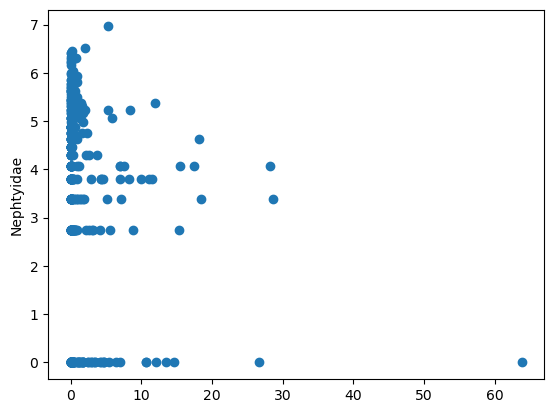

In [27]:
X_train.shape
# X_first_two = X_train.iloc[:,1:3]
# X_test_two = X_test.iloc[:,1:3]




# X_first_two, X_test_two



# # 
plt
plt.scatter(X_train.iloc[:,0], y_train)
plt.ylabel("Nephtyidae")

# plt.hist(X_train.iloc[:,19])

In [28]:
mean_X = pd.DataFrame(np.mean(X_train, axis=0))  # Mean of each predictor
std_X = np.std(X_train, axis=0)    # Standard deviation of each predictor


In [29]:
# labels = [f"coeff_{i}" for i in range(X_train.shape[1])]
# coords = {"coeffs": labels}
# mean_X = X_train.mean(axis=0).values
# std_X = X_train.std(axis=0).values 

# with pm.Model(coords=coords) as model:
#     X = pm.MutableData("X", X_train)
#     y = pm.MutableData("y", y_train+0.001)
#     b = pm.Normal("b", mu=50, sigma=50, dims="coeffs")

#     # v = pm.HalfNormal("v", sigma = 20)

#     sigma = pm.HalfNormal("sigma", sigma=y.std())
#     # delta = pm.HalfNormal("delta",sigma = 10, dims="coeffs")
#     # sigma = pm.math.dot(X, delta)

#     mu = pm.math.dot(X, b)
#     # y_obs = pm.Exponential("y_obs",lam=1/mu, observed=y)
#     y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y)

#     # y_obs = pm.StudentT("y_obs", mu=mu, sigma=sigma, nu=v, observed=y)

# pm.model_to_graphviz(model)


In [30]:
# with model:
#     step = pm.NUTS(target_accept=0.95)
#     trace = pm.sample(step=step, draws=1000)
    # trace = pm.sample()

/home/julian/miniconda3/envs/pymc-bart/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)



 Random Forest regressor
Mean Absolute Error (MAE): 0.911
Mean Squared Error (MSE): 1.194
Root Mean Squared Error (RMSE): 1.093
R-squared (R2): 0.722


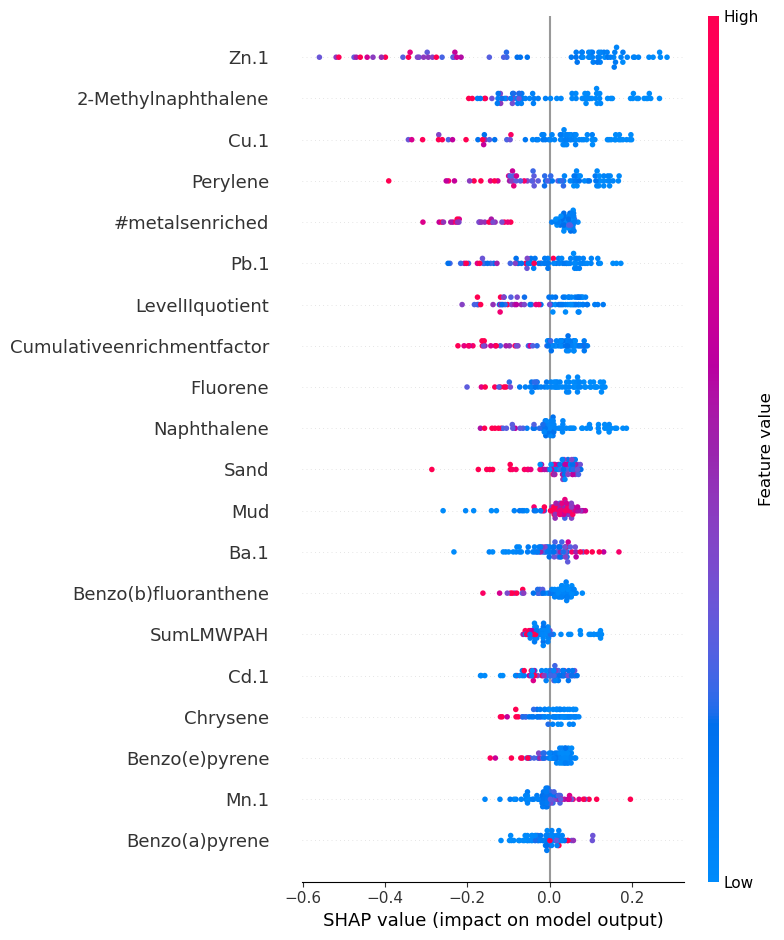

In [70]:
# model = RandomForestRegressor(max_depth= None, max_features= 'sqrt', min_samples_leaf= 4, min_samples_split= 2, n_estimators= 50, random_state=42)#, criterion='absolute_error')
model = RandomForestRegressor(max_depth= None, max_features= 'sqrt', min_samples_leaf= 4, min_samples_split= 2, n_estimators= 100, random_state=42)
model.fit(X_train, np.log1p(y_train))
y_pred = np.exp(model.predict(X_test))
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# scores = cross_val_score(model, X_train, y_train, cv=5, scoring="neg_mean_squared_error")

# # Convert scores to positive values and calculate mean RMSE
# rmse_scores = (-scores) ** 0.5
# print(f"RMSE for each fold: {rmse_scores}")
# print(f"Mean RMSE: {rmse_scores.mean()}")

# Print results
# print(f"R^2 scores for each fold: {scores}")
# print(f"Average R^2: {average_r2}")


print("\n Random Forest regressor")
print(f"Mean Absolute Error (MAE): {mae:.3f}")
print(f"Mean Squared Error (MSE): {mse:.3f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.3f}")
print(f"R-squared (R2): {r2:.3f}")

explainer = shap.TreeExplainer(model, X_train)

shap_values = explainer(X_test, check_additivity=False)

shap_values_list = []
shap.summary_plot(shap_values, X_test, show=False, feature_names=X_train.columns)
# _remake_data(shap_values, 5)

In [58]:
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

params = {
    'objective': 'reg:squarederror',  # Loss function for regression task
    'eval_metric': 'rmsle',             # Evaluation metric
    'eta': 0.01,                        # Learning rate
    'max_depth': 5,                    # Maximum depth of each tree
    'subsample': 0.8,                  # Subsample ratio of the training instances
    'colsample_bytree': 0.8,           # Subsample ratio of columns when constructing each tree
    'seed': 42,
    # 'alpha': 0.2,
    # 'gamma': 0.9
}

num_rounds = 100  # Number of boosting rounds
# xgbModel = xgb.train(params, dtrain, num_rounds)
xgbModel = xgb.XGBRegressor(
    objective="reg:squarederror",
    max_depth=5,
    learning_rate=0.1,
    n_estimators=100,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
    )

scores = cross_val_score(xgbModel, X_train, y_train, cv=5, scoring="r2")
average_r2 = np.mean(scores)

# Print results
print(f"R^2 scores for each fold: {scores}")
print(f"Average R^2: {average_r2}")

# cv_results = cv_results = xgb.cv(
#     params,
#     dtrain,
#     num_boost_round=100,  # Maximum number of boosting rounds
#     nfold=5,  # Number of folds
#     metrics="rmse",  # Evaluation metric
#     early_stopping_rounds=10,  # Stop early if no improvement
#     seed=42
# )
# print(cv_results)

# print(f"Best RMSE: {cv_results['test-rmse-mean'].min()}")

# Make predictions on the test set
y_pred = xgbModel.predict(dtest)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)


print("\n Random Forest regressor")
print(f"Mean Absolute Error (MAE): {mae:.3f}")
print(f"Mean Squared Error (MSE): {mse:.3f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.3f}")
print(f"R-squared (R2): {r2:.3f}")

explainer = shap.TreeExplainer(xgbModel, X_train)

shap_values = explainer(X_test, check_additivity=False)

shap_values_list = []
shap.summary_plot(shap_values, X_test, show=False, feature_names=X_train.columns)

R^2 scores for each fold: [0.22750938 0.12309587 0.27246308 0.36005771 0.26827997]
Average R^2: 0.2502812027931213


NotFittedError: need to call fit or load_model beforehand

In [19]:
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [100, 200, 300],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1]
}

xgb_model = xgb.XGBRegressor()
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, scoring='neg_mean_squared_error', cv=3, verbose=1)
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)

Fitting 3 folds for each of 108 candidates, totalling 324 fits
Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 300, 'subsample': 0.8}


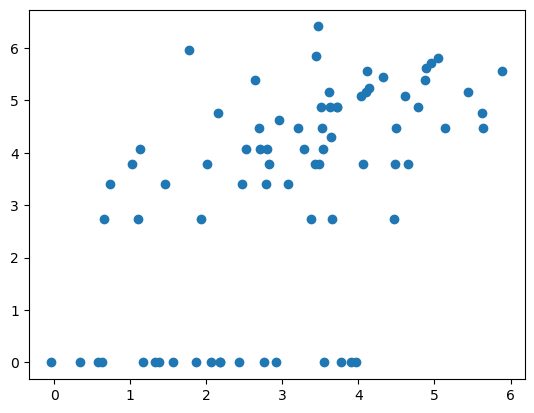

In [25]:
plt.scatter(y_pred, y_test)

In [33]:
# rf = RandomForestRegressor(random_state=42)

# param_grid = {
#     'n_estimators': [50, 100, 200],
#     'max_depth': [None, 10, 20, 30],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4],
#     'max_features': ['auto', 'sqrt', 'log2']
# }

# grid_search = GridSearchCV(
#     estimator=rf,
#     param_grid=param_grid,
#     scoring='neg_mean_squared_error',  
#     cv=5,
#     n_jobs=-1,
#     verbose=0
# )

# grid_search.fit(X_train, y_train)

# print("Best parameters found: ", grid_search.best_params_)
# print("Best score: ", grid_search.best_score_)

# y_pred = grid_search.best_estimator_.predict(X_test)
# y_pred = model.predict(X_test)
# mse = mean_squared_error(y_test, y_pred)
# rmse = np.sqrt(mse)
# mae = mean_absolute_error(y_test, y_pred)
# r2 = r2_score(y_test, y_pred)


# print("\n Random Forest regressor")
# print(f"Mean Absolute Error (MAE): {mae:.3f}")
# print(f"Mean Squared Error (MSE): {mse:.3f}")
# print(f"Root Mean Squared Error (RMSE): {rmse:.3f}")
# print(f"R-squared (R2): {r2:.3f}")
# explainer = shap.TreeExplainer(model, X_train)

# shap_values = explainer(X_test, check_additivity=False)

# shap_values_list = []
# shap.summary_plot(shap_values, X_test, show=False, feature_names=X_train.columns)

In [34]:
# shap_df = pd.DataFrame(shap_values.values, columns=X_test.columns)

# feature_importance = shap_df.abs().mean().sort_values(ascending=False)
# ranked_features = feature_importance.reset_index()
# ranked_features.columns = ['Feature', 'Mean Absolute SHAP Value']
# ranked_features['Rank'] = ranked_features['Mean Absolute SHAP Value'].rank(ascending=False)
# print("Ranked Features DataFrame:\n", ranked_features)

# # print(ranked_features)

# top_features = ranked_features['Feature'].head(20).tolist()
# X_train = X_train[top_features]
# # self.y_train_scaled = self.y_train_scaled.values.ravel()
# X_test = X_test[top_features]
# # self.y_test_scaled = self.y_test_scaled.values.ravel()

# # self.X_train_scaled = self._concatDF(self.X_train_scaled, self.X_train_locations)
# # self.X_test_scaled = self._concatDF(self.X_test_scaled, self.X_test_locations)
# print(X_train)

In [35]:
labels = [f"coeff_{i}" for i in range(X_train.shape[1])]
coords = {"coeffs": labels}
mean_X = X_train.mean(axis=0).values
std_X = X_train.std(axis=0).values 

# X_train = np.asarray(X_train)
# y_train = np.asarray(y_train) + 0.001

In [36]:
prop_zero = np.mean(y_train==0)
print("Proportion of zeros:", prop_zero)
print(y_train)
alpha = prop_zero 
beta = (1 - prop_zero)
y_var = np.var(y_train)
y_var

Proportion of zeros: 0.27440633245382584
[3.39635341 3.39635341 3.39635341 0.         4.62490039 5.44604859
 5.3131332  5.44604859 5.61721757 4.07261117 0.         3.79059066
 4.07261117 3.39635341 5.38179759 4.75720545 0.         5.23940411
 5.50641946 5.3131332  4.75720545 0.         3.39635341 0.
 0.         4.07261117 3.79059066 2.73615268 0.         0.
 0.         2.73615268 2.73615268 0.         2.73615268 3.39635341
 4.47238248 2.73615268 0.         0.         0.         0.
 4.47238248 0.         3.79059066 3.39635341 0.         0.
 0.         5.66832911 4.97862961 3.79059066 4.47238248 4.87403363
 5.76332527 5.50641946 5.38179759 4.87403363 5.23940411 0.
 4.87403363 4.75720545 0.         2.73615268 4.62490039 0.
 2.73615268 2.73615268 2.73615268 0.         3.79059066 0.
 0.         0.         2.73615268 2.73615268 0.         4.87403363
 4.07261117 3.79059066 4.87403363 4.75720545 0.         0.
 2.73615268 5.07331382 3.79059066 5.07331382 5.23940411 3.79059066
 3.79059066 3.3963

4.424871093251107

In [37]:
from pymc.math import constant

# z = pm.Bernoulli("z", p=π, shape=y.shape[0])
    
#     # Weibull parameters
#     alpha = pm.HalfNormal("alpha", sigma=1)
#     beta = pm.HalfNormal("beta", sigma=1)
    
#     # Observations
#     y_obs = pm.DensityDist(
#         "y_obs",
#         lambda value: pm.math.switch(
#             z,
#             pm.Normal.dist(mu=0, sigma=1e-6).logp(value),  # Zero distribution
#             pm.Weibull.dist(alpha=alpha, beta=beta).logp(value)  # Weibull
#         ),
#         observed=y
#     )

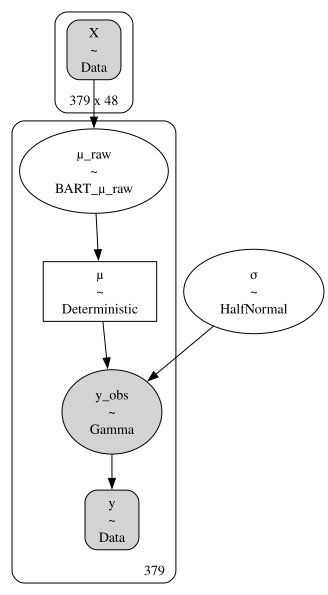

In [38]:


with pm.Model() as bart_g:
    X = pm.Data("X", X_train+0.0001)
    y = pm.Data("y", y_train+0.0001)
    # π = pm.Beta("π", alpha=alpha, beta=beta)  # π is the probability of zero
    # π = pm.Beta("π", alpha=1, beta=1)

    # Zero-inflation: Bernoulli likelihood
    # zero_inflation = pm.Bernoulli("zero_inflation", p=π, observed=(y == 0.0))

    
    σ = pm.HalfNormal("σ", sigma=10)
    # σ = pm.Beta("σ", alpha=1, beta=1.3)
    μ_raw= pmb.BART("μ_raw", X, y.get_value(), m=100)
    # μ = pm.Deterministic("μ", pm.math.log(1 + pm.math.exp(μ_raw)))
    μ = pm.Deterministic("μ", pm.math.switch(μ_raw <= 0, 0.0001, μ_raw))
    # μ = pm.Deterministic("μ", pm.math.log(1 + pm.math.exp(μ_raw)))
    # y_obs = pm.Normal("y_obs", mu=μ_raw, sigma=σ, observed=y)
    y_obs = pm.Gamma("y_obs", mu=μ, sigma=σ, observed=y)
    # y_obs = pm.Mixture(
    # "y_obs",
    # w=[π, 1 - π],  # Zero-inflated weight and regular distribution weight
    # comp_dists=[
    #     pm.math.constant.dist(mu=0, sigma=1e-2),  # Continuous approximation of zero
    #     pm.Normal.dist(mu=μ_raw, sigma=σ),  # Normal for non-zero observations
    # ],
    # observed=y
    # )
    # μ_raw = pm.Deterministic("μ_raw", pm.math.switch(μ_raw <= 0, 0.0, μ_raw))

    # z = pm.Bernoulli("z", p=π, shape=y.shape[0])

    # y_obs = pm.Normal( #replaced z with zero_inflation
    #     "y_obs",
    #     mu=pm.math.switch(zero_inflation, 0, μ_raw),  # Zero when zero_inflation=1, else Normal(mu, sigma)
    #     sigma=pm.math.switch(zero_inflation, 1e-6, σ),
    #     observed=y
    # )

pm.model_to_graphviz(bart_g)

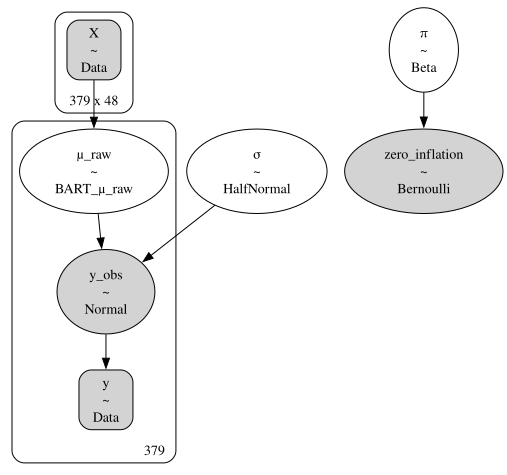

In [39]:
"""Do Grid Search on sigma, m, chains, draws, tune, target_accuracy"""

with pm.Model() as bart_g:
    X = pm.Data("X", X_train)
    y = pm.Data("y", y_train)
    π = pm.Beta("π", alpha=alpha, beta=beta)  # π is the probability of zero
    # π = pm.Beta("π", alpha=1, beta=1)

    # Zero-inflation: Bernoulli likelihood
    zero_inflation = pm.Bernoulli("zero_inflation", p=π, observed=(y == 0.0))

    σ = pm.HalfNormal("σ", sigma=10)
    # σ = pm.Weibull("σ", alpha=1.5,beta=1)
    # σ = pm.Beta("σ", alpha=1, beta=1.3)
    μ_raw= pmb.BART("μ_raw", X, y.get_value(), m=80)
    # μ = pm.Deterministic("μ", pm.math.log(1 + pm.math.exp(μ_raw)))
    # μ = pm.Deterministic("μ", pm.math.switch(μ_raw <= 0, 0.0, μ_raw))
    # μ = pm.Deterministic("μ", pm.math.log(1 + pm.math.exp(μ_raw)))
    y_obs = pm.Normal("y_obs", mu=μ_raw, sigma=σ, observed=y)


    # y_obs = pm.Mixture(
    # "y_obs",
    # w=[π, 1 - π],  # Zero-inflated weight and regular distribution weight
    # comp_dists=[
    #     pm.math.constant.dist(mu=0, sigma=1e-2),  # Continuous approximation of zero
    #     pm.Normal.dist(mu=μ_raw, sigma=σ),  # Normal for non-zero observations
    # ],
    # observed=y
    # )
    # μ_raw = pm.Deterministic("μ_raw", pm.math.switch(μ_raw <= 0, 0.0, μ_raw))

    # z = pm.Bernoulli("z", p=π, shape=y.shape[0])

    # y_obs = pm.Normal( #replaced z with zero_inflation
    #     "y_obs",
    #     mu=pm.math.switch(zero_inflation, 0, μ_raw), # 0 when z=1, else Normal(mu, sigma)
    #     sigma=pm.math.switch(zero_inflation, 1e-6, σ),
    #     observed=y
    # )

pm.model_to_graphviz(bart_g)


In [40]:
y_positive = y_train[y_train > 0]  # Non-zero values
y_zero = (y_train == 0)
y_zero

array([False, False, False,  True, False, False, False, False, False,
       False,  True, False, False, False, False, False,  True, False,
       False, False, False,  True, False,  True,  True, False, False,
       False,  True,  True,  True, False, False,  True, False, False,
       False, False,  True,  True,  True,  True, False,  True, False,
       False,  True,  True,  True, False, False, False, False, False,
       False, False, False, False, False,  True, False, False,  True,
       False, False,  True, False, False, False,  True, False,  True,
        True,  True, False, False,  True, False, False, False, False,
       False,  True,  True, False, False, False, False, False, False,
       False, False, False, False, False,  True, False,  True, False,
       False, False, False,  True,  True,  True,  True, False,  True,
       False, False, False, False,  True,  True, False, False, False,
       False,  True, False, False,  True, False, False, False, False,
       False, False,

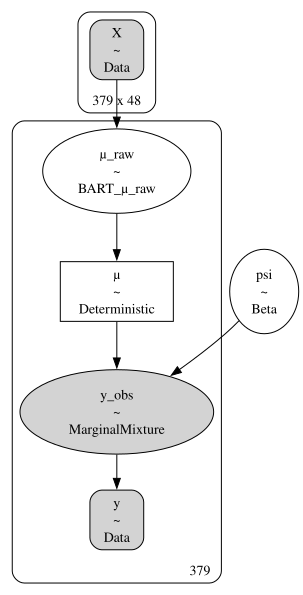

In [41]:
# Zero_check = RandomForestClassifier()
# Zero_check.fit(X_train, y_train)
# def zi_gp_lmpf(psi, delta, lam, y):
    # l1 = pm.math.log(lam)+(y-1)*pm.math.log(lam+delta*y)
    # l2 = lam+delta*y+pm.math.gammaln(y+1)
    # LL = l1-l2
    # return pm.math.switch(pm.math.eq(y,0),pm.math.log(1-psi+psi*pm.math.exp(-lam)),pm.math.log(psi)+LL)


with pm.Model() as bart_g:

    # Data
    X = pm.Data("X", X_train)
    y = pm.Data("y", y_train)

    # Priors
    # π = pm.Beta("π", alpha=3, beta=1)  # Zero-inflation probability
    # σ = pm.HalfNormal("σ", sigma=10)         # Noise standard deviation
    # λ = pm.HalfNormal("λ", sigma=10)
    psi = pm.Beta("psi", alpha=2, beta=2)

    # beta = pm.Normal('beta', mu=0, sigma=100, shape=X.get_value().shape['K'])
    # deltap = pm.Uniform('delta', lower=-1, upper=1)
    # psip = pm.Uniform('delta', lower=0, upper=1)


    

    #zeros = Zero_check.predict(X)

    # BART for non-zero values
    μ_raw = pmb.BART("μ_raw", X, y.get_value(), m=100, separate_trees=True)
    # μ = pm.Deterministic("μ", pm.math.switch(μ_raw <= 0, 0.0001, μ_raw))
    μ = pm.Deterministic("μ", pm.math.abs(μ_raw))

    # lamda=(1-deltap)*pm.math.exp(μ)


    # zero_prob = pm.Deterministic("zero_prob", pm.invlogit(μ_raw))
    y_obs = pm.HurdlePoisson("y_obs", mu=μ, psi=psi, observed=y) # when target is log transformed
    # y_zeros = (pm.math.eq(y,0).astype(int))
    # y_abs = pm.Bernoulli("y_abs", p=zero_prob, observed=y_zeros)

    # y_obs = pm.ZeroInflatedPoisson("y_obs", mu=μ, psi=π, observed=y)  

    # # Zero likelihood
    # μ_zeros = pmb.BART("μ_zeros", X, (y.get_value() == 0).astype(int), m=100, separate_trees=True)

    # zero_prob = pm.Deterministic("zero_prob", pm.invlogit(μ_zeros))  # Logistic transformation
    # print(y.get_value())
    # y_abs = pm.Bernoulli("y_abs", p=zero_prob, observed=(y.get_value()==0))


    

    # y_obs = pm.Exponential("y_obs", lam=1 / μ, observed=y)
    # y_obs = pm.HalfNormal("y_obs", sigma=μ, observed=y)
    # y_obs = pm.Exponential("y_obs", lam=1/(μ), observed=y)

    # zero_component = pm.ZeroInflatedPoisson.dist(mu=μ, psi=0.5)  # Zero-inflated Poisson
    # non_zero_component = pm.Poisson.dist(mu=μ)  # Poisson distribution

    # # Mixture model
    # y_obs = pm.Mixture(
    #     "y_obs",
    #     w=[π, 1 - π],
    #     comp_dists=[zero_component, non_zero_component],
    #     observed=y,
    # )
    
    
    # y_obs = pm.Mixture(
    #     "y_obs",
    #     w=[π, 1 - π],  # Mixture weights for zero and non-zero parts
    #     comp_dists=[
    #         pm.Normal.dist(mu=0, sigma=1e-6),       # Zero-inflated component
    #         # pm.Normal.dist(mu=μ_raw, sigma=σ),      # Continuous part
    #         pm.ZeroInflatedPoisson.dist( mu=μ, psi=p) 
    #         # pm.HalfNormal.dist(mu=pm.math.log(μ_raw), sigma=σ),      # Continuous part
    #         # pm.Exponential.dist(lam=1 / μ_raw),
    #     ],
    #     observed=y,
    # )
    


# with pm.Model() as bart_zero:
#     X = pm.Data("X", X_train)
#     y = pm.Data("y", (y_train == 0).astype(int))
#     # zero_inflation_mask = np.where(y.get_value() == 0, 1, 0)
#     # print(zero_inflation_mask)
#     # print(y_train)
#     μ_zeros = pmb.BART("μ_zeros", X, y.get_value(), m=20, separate_trees=True)
#     zero_prob = pm.Deterministic("zero_prob", pm.invlogit(μ_zeros))  # Logistic transformation
#     print(y.get_value())
#     y_abs = pm.Bernoulli("y_abs", p=zero_prob, observed=y)


pm.model_to_graphviz(bart_g)
# pm.model_to_graphviz(bart_zero)



In [42]:
with bart_g:

    trace = pm.sample(1000, chains=4, tune=1000, target_accept=0.95, return_inferencedata=True)

# with bart_zero:

#     zero_trace = pm.sample(1000, chains=4, tune=1000, target_accept=0.95, return_inferencedata=True,step=pm.Metropolis())


Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [psi]
>PGBART: [μ_raw]


Output()

ValueError: Not enough samples to build a trace.

In [86]:
# X_train_np = X_train.to_numpy()
# y_train_np = y_train
# X_test_np = X_test.to_numpy()
# y_test_np = y_test
# y_zeros = (y_train_np > 0)
# with pm.Model() as hurdle_model:
#     # Define data containers for predictors and outcomes
#     X_data = pm.Data("X_data", X_train_np)
#     y_data = pm.Data("y_data", y_train_np)
#     y_zeros = pm.Data("y_zeros", y_zeros)
    
#     # Number of predictors
#     n_predictors = X_train_np.shape[1]
    
#     # Priors for logistic regression (binary component)
#     beta_zero = pm.Normal("beta_zero", mu=0, sigma=10, shape=n_predictors)
#     intercept_zero = pm.Normal("intercept_zero", mu=0, sigma=10)
    
#     # Logistic regression for zero-inflation
#     logit_p = intercept_zero + pm.math.dot(X_data, beta_zero)
#     p_zero = pm.Deterministic("p_zero", pm.math.sigmoid(logit_p))
#     # Binary observed outcome (zero vs. non-zero abundance)
#     zero_inflation_obs = pm.Bernoulli(
#         "zero_inflation_obs", p=p_zero, observed=y_zeros
#     )
    
#     # Priors for positive abundance (Poisson for y_data > 0)
#     beta_pos = pm.Normal("beta_pos", mu=0, sigma=10, shape=n_predictors)
#     intercept_pos = pm.Normal("intercept_pos", mu=0, sigma=10)
    
#     # Linear predictor for positive abundance
#     mu_pos = pm.math.exp(intercept_pos + pm.math.dot(X_data, beta_pos))
    
#     # Mask zeros for the Poisson likelihood
#     positive_abundance_mask = y_data > 0
#     abundance_pos = pm.Normal(
#         "abundance_pos", mu=mu_pos, observed=y_data
#     )
    
#     # Sampling
#     trace = pm.sample(1000, tune=1000, target_accept=0.95, random_seed=42)

# # Test the model on X_test and y_test
# with hurdle_model:
#     # Update data containers with test data
#     pm.set_data({"X_data": X_test_np, "y_data": y_test_np})
    
#     # Perform posterior predictive checks
#     posterior_predictive = pm.sample_posterior_predictive(trace, var_names=["p_zero", "abundance_pos"])


In [87]:
# # Test the model on X_test and y_test
# with hurdle_model:
#     # Update data containers with test data
#     pm.set_data({"X_data": X_test_np, "y_data":np.zeros_like(y_test_np.values.ravel())})
    
#     # Perform posterior predictive checks
#     posterior_predictive = pm.sample_posterior_predictive(trace, var_names=["p_zero", "abundance_pos"])

# # Analyze the posterior predictions
# # `p_zero`: Probability of non-zero abundance
# # `abundance_pos`: Predicted positive abundance values for non-zero cases
# p_zero_pred = posterior_predictive.posterior_predictive["p_zero"].mean(axis=0)
# abundance_pred = posterior_predictive.posterior_predictive["abundance_pos"].mean(axis=0)

# # Combine predictions
# final_predictions = p_zero_pred * abundance_pred

# # Print results
# print("Predicted Probabilities of Non-Zero Abundance (p_zero):", p_zero_pred.data)
# print("Predicted Positive Abundance (abundance_pos):", abundance_pred.data)
# print("Final Combined Predictions:", final_predictions.data)

# # Optional: Visualize posterior summaries
# az.plot_posterior(posterior_predictive.posterior_predictive["abundance_pos"], hdi_prob=0.95)

In [88]:
# pres = y_train > 0
# abs = y_train == 0

# with pm.Model() as single_bart_model:
#     X = pm.Data("X", X_train)
#     y = pm.Data("y", y_train)
#     # Single BART for log-biomass predictions
#     bart_output = pmb.BART("bart_output", X=X, Y=np.log1p(y_train), m=50)

#     # Probability of presence (log-odds to probability for zero/non-zero separation)
#     p = pm.Deterministic("p", pm.math.sigmoid(bart_output))  # For zeros vs. presence
#     is_nonzero = pm.Bernoulli("is_nonzero", p, observed=(y_train > 0).astype(int))

#     # Mean biomass for positive observations (log-transformed scale)
#     mu = pm.Deterministic("mu", pm.math.exp(bart_output))  # Convert log-biomass back
#     mupres = mu[pres]  # Only include positive biomass observations

#     # Observation model for presence data
#     ngis = pm.Poisson("ngis", mu=mupres, shape=len(y_train[pres]))
#     a = pm.HalfNormal("a", sigma=1)
#     b = pm.HalfNormal("b", sigma=1)
#     Ya = pm.Deterministic("Ya", a * ngis)
#     Y_pres = pm.Gamma("Y_pres", alpha=Ya, beta=b, observed=y_train[pres])

#     # Sampling
#     trace = pm.sample(1000, tune=1000, target_accept=0.9, return_inferencedata=True)



# # pm.model_to_graphviz(bart_zeros_model)
#     # Sampling
# # with bart_zeros_model:
# #     trace = pm.sample(1000, tune=1000, target_accept=0.9)

# # az.plot_trace(trace)
# # plt.show()

# # Posterior summaries


In [89]:
# pm.model_to_graphviz(single_bart_model)


In [90]:
# with single_bart_model:
    
#     ppc = pm.sample_posterior_predictive(trace)

# predicted_biomass = ppc.posterior_predictive["Y_pres"].mean(dim=["chain", "draw"])  # Averaged over the posterior for predicted biomass

# # ppc["is_nonzero"] contains the posterior predictive samples for the presence probabilities
# predicted_presence = ppc.posterior_predictive["is_nonzero"].mean(dim=["chain", "draw"])  # Averaged over the posterior for probability of presence

# # Separate presence and absence data for evaluation
# predicted_biomass_pres = predicted_biomass[pres]  # Predicted biomass for presence sites (where y > 0)
# actual_biomass_pres = y_train[pres]  # Actual biomass for presence sites (observed data)

# # Metrics for positive biomass predictions
# rmse = np.sqrt(mean_squared_error(actual_biomass_pres, predicted_biomass_pres))
# mae = mean_absolute_error(actual_biomass_pres, predicted_biomass_pres)
# r2 = r2_score(actual_biomass_pres, predicted_biomass_pres)

# print(f"RMSE (Presence): {rmse:.2f}")
# print(f"MAE (Presence): {mae:.2f}")
# print(f"R² (Presence): {r2:.2f}")

# # Metrics for presence/absence classification
# # Convert predicted presence probabilities into binary presence/absence
# predicted_presence_binary = (predicted_presence > 0.5).astype(int)  # Threshold at 0.5 for presence/absence
# accuracy = np.mean(predicted_presence_binary == (y_train > 0).astype(int))  # Compare with actual presence/absence
# print(f"Accuracy (Presence/Absence): {accuracy:.2%}")

# # Visualization: Predicted vs. Actual Biomass (for presence sites only)
# plt.figure(figsize=(10, 5))
# plt.scatter(actual_biomass_pres, predicted_biomass_pres, alpha=0.5)
# plt.plot([0, actual_biomass_pres.max()], [0, actual_biomass_pres.max()], "r--")
# plt.xlabel("Actual Biomass")
# plt.ylabel("Predicted Biomass")
# plt.title("Predicted vs. Actual Biomass (Presence)")
# plt.show()


In [91]:
# ppc

In [92]:
# # plt.scatter(x=(binary_ppc< 0.5).astype(int), y=(y_train==0).astype(int))
# plt.hist((binary_ppc>= 0.5).astype(int))
# plt.hist((y_train>0).astype(int))

/home/julian/miniconda3/envs/pymc-bart/lib/python3.12/site-packages/arviz/plots/plot_utils.py:270: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of variables to plot (607) in plot_posterior, generating only 40 plots
  warnings.warn(


array([[<Axes: title={'center': 'μ_raw\n0'}>,
        <Axes: title={'center': 'μ_raw\n1'}>,
        <Axes: title={'center': 'μ_raw\n2'}>,
        <Axes: title={'center': 'μ_raw\n3'}>],
       [<Axes: title={'center': 'μ_raw\n4'}>,
        <Axes: title={'center': 'μ_raw\n5'}>,
        <Axes: title={'center': 'μ_raw\n6'}>,
        <Axes: title={'center': 'μ_raw\n7'}>],
       [<Axes: title={'center': 'μ_raw\n8'}>,
        <Axes: title={'center': 'μ_raw\n9'}>,
        <Axes: title={'center': 'μ_raw\n10'}>,
        <Axes: title={'center': 'μ_raw\n11'}>],
       [<Axes: title={'center': 'μ_raw\n12'}>,
        <Axes: title={'center': 'μ_raw\n13'}>,
        <Axes: title={'center': 'μ_raw\n14'}>,
        <Axes: title={'center': 'μ_raw\n15'}>],
       [<Axes: title={'center': 'μ_raw\n16'}>,
        <Axes: title={'center': 'μ_raw\n17'}>,
        <Axes: title={'center': 'μ_raw\n18'}>,
        <Axes: title={'center': 'μ_raw\n19'}>],
       [<Axes: title={'center': 'μ_raw\n20'}>,
        <Axes: tit

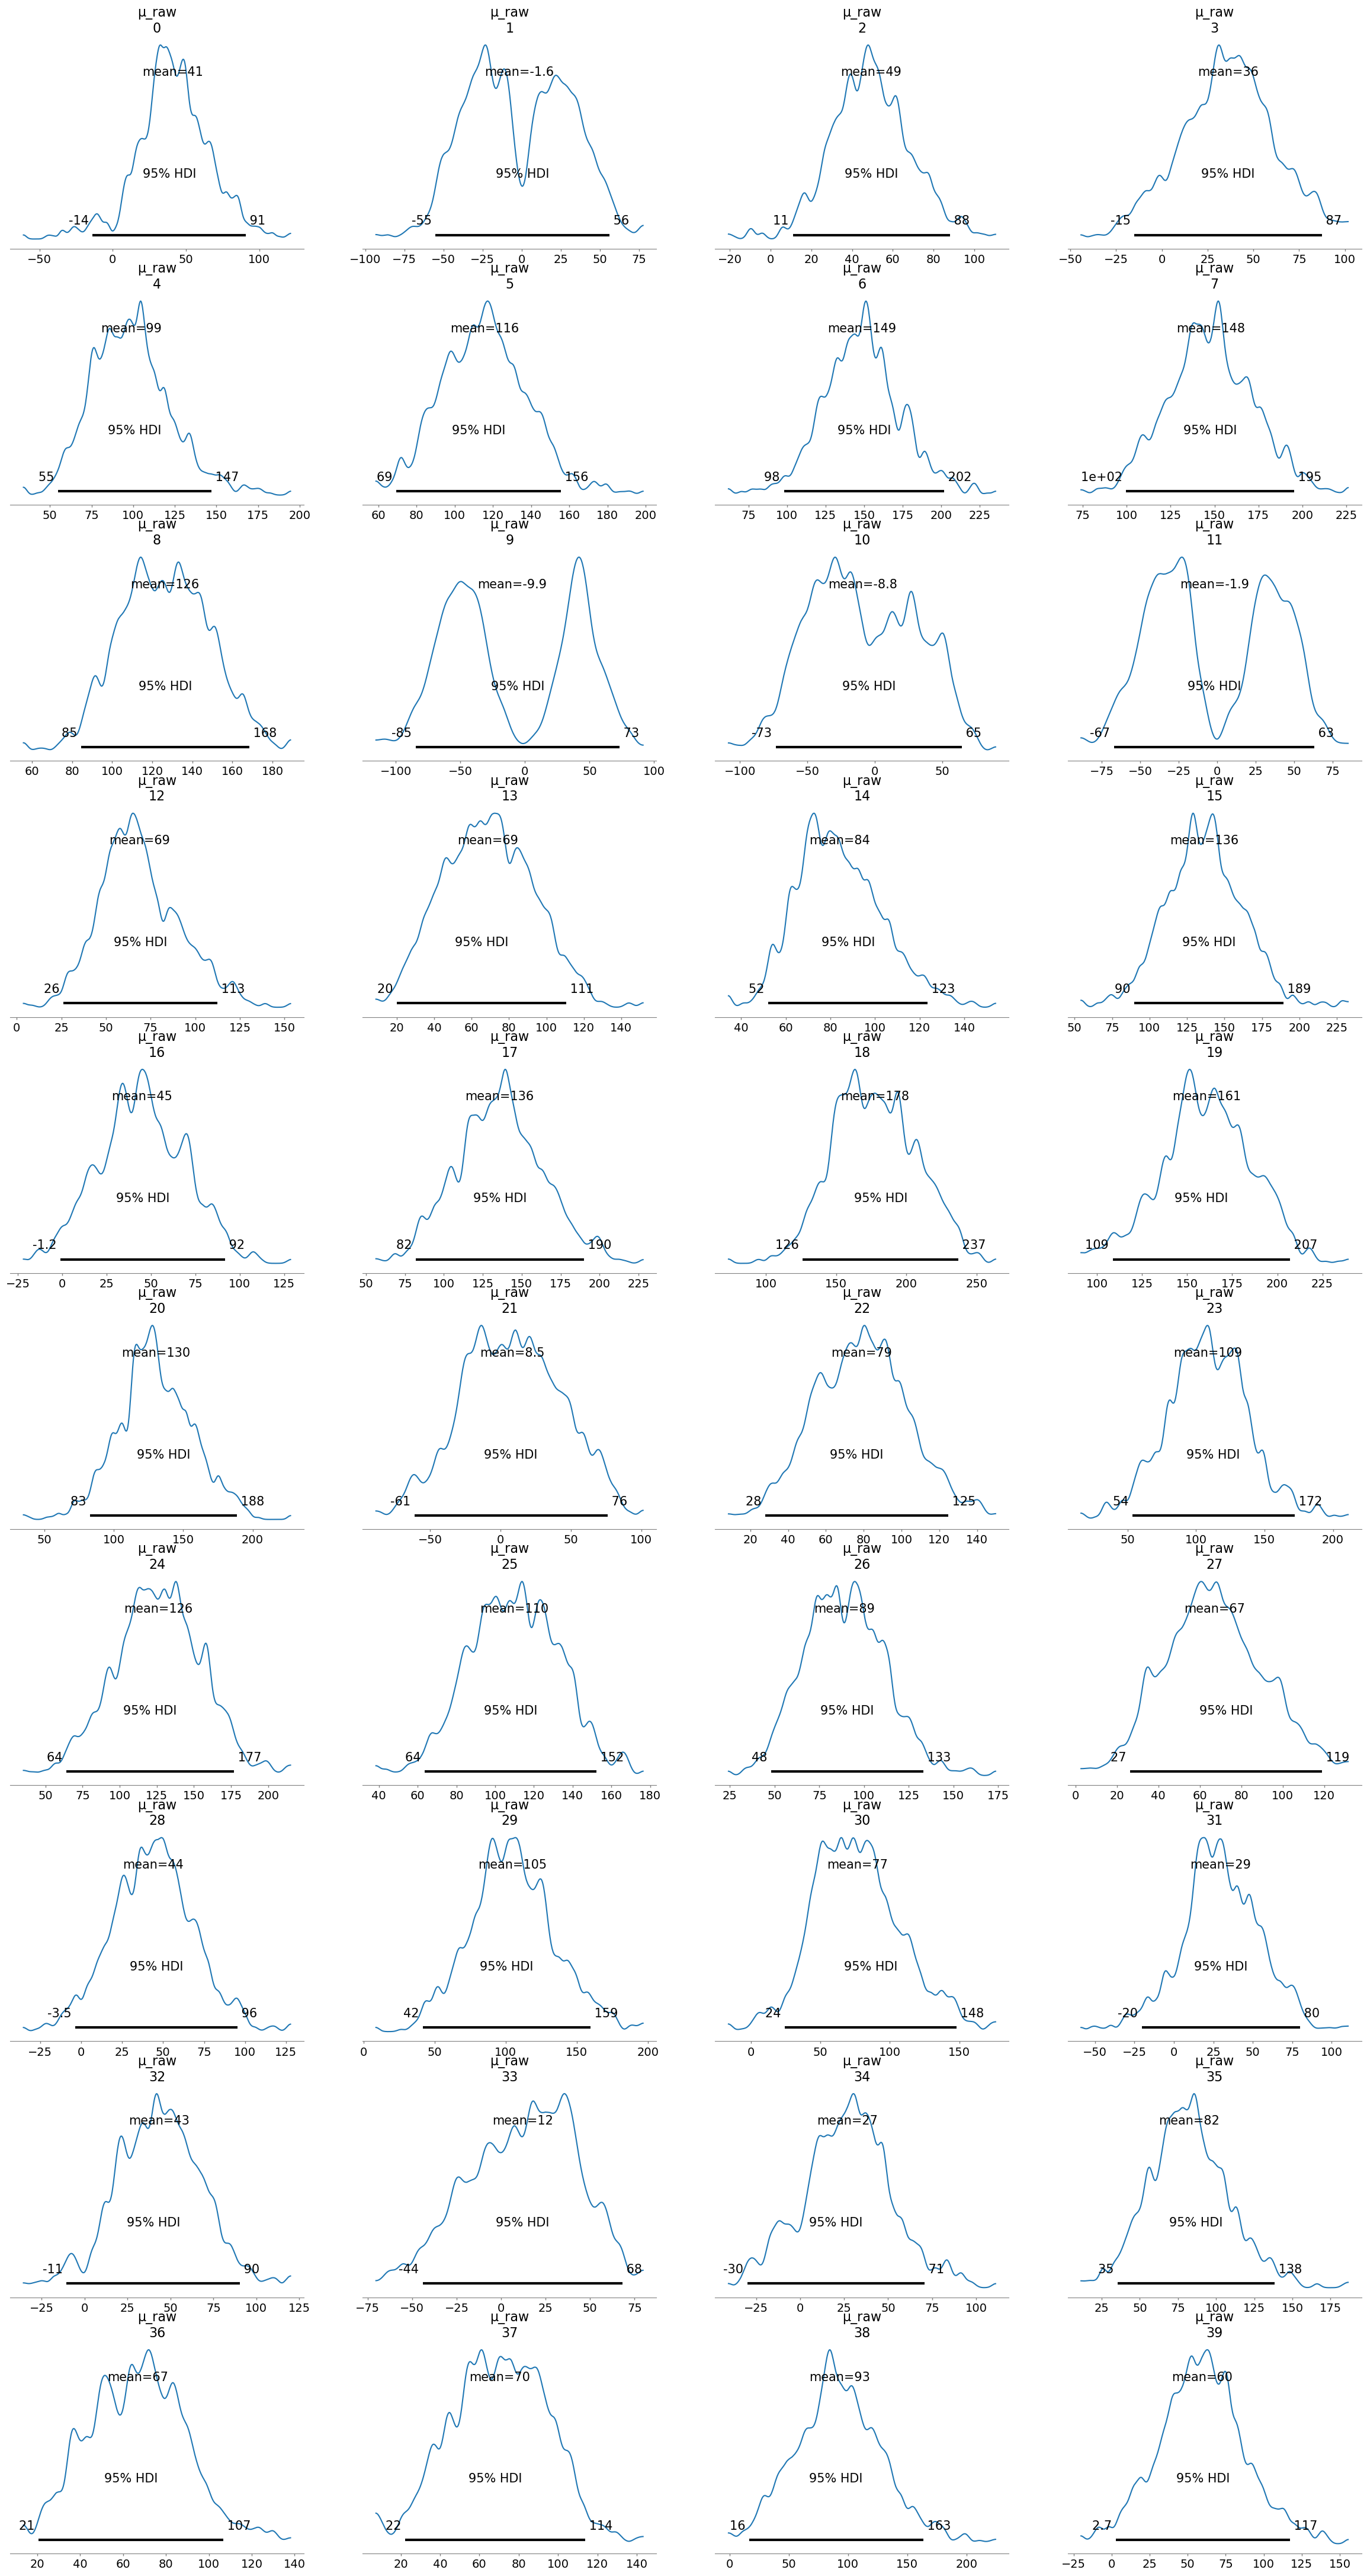

In [93]:
az.plot_posterior(trace, hdi_prob=0.95, var_names=X_train.columns)

In [94]:
# import bambi as bmb

# fauna = pd.read_csv("Spionidae/fauna.csv",
#         sep=",",
#         encoding="utf-8")
# fauna["Spionidae"] = fauna["Spionidae"].round()
# hurdle_formula = bmb.Formula(
#     "Spionidae ~ Gravel + Mud + Totalorganiccontent + Sand + Fe.1 + As.1 + Ba.1", # parent parameter mu
#     "psi ~ Gravel + Mud + Totalorganiccontent + Sand + Fe.1 + As.1 + Ba.1"    # non-parent parameter psi
# )

# hurdle_model = bmb.Model(
#     hurdle_formula, 
#     fauna, 
#     family='hurdle_poisson'
# )

# hurdle_idata = hurdle_model.fit(
#     draws=1000, 
#     target_accept=0.99, 
#     random_seed=1234, 
#     chains=1
# )

In [95]:
# hurdle_model.graph()

In [96]:
# hurdle_pps = hurdle_model.predict(idata=hurdle_idata, kind="response", inplace=False)
# 

In [97]:
# from matplotlib.lines import Line2D

# def adjust_lightness(color, amount=0.5):
#     import matplotlib.colors as mc
#     import colorsys
#     try:
#         c = mc.cnames[color]
#     except:
#         c = color
#     c = colorsys.rgb_to_hls(*mc.to_rgb(c))
#     return colorsys.hls_to_rgb(c[0], c[1] * amount, c[2])

# def plot_ppc_discrete(idata, bins, ax):
    
#     def add_discrete_bands(x, lower, upper, ax, **kwargs):
#         for i, (l, u) in enumerate(zip(lower, upper)):
#             s = slice(i, i + 2)
#             ax.fill_between(x[s], [l, l], [u, u], **kwargs)

#     var_name = list(idata.observed_data.data_vars)[0]
#     y_obs = idata.observed_data[var_name].to_numpy()
    
#     counts_list = []
#     for draw_values in az.extract(idata, "posterior_predictive")[var_name].to_numpy().T:
#         counts, _ = np.histogram(draw_values, bins=bins)
#         counts_list.append(counts)
#     counts_arr = np.stack(counts_list)

#     qts_90 = np.quantile(counts_arr, (0.05, 0.95), axis=0)
#     qts_70 = np.quantile(counts_arr, (0.15, 0.85), axis=0)
#     qts_50 = np.quantile(counts_arr, (0.25, 0.75), axis=0)
#     qts_30 = np.quantile(counts_arr, (0.35, 0.65), axis=0)
#     median = np.quantile(counts_arr, 0.5, axis=0)

#     colors = [adjust_lightness("C0", x) for x in [1.8, 1.6, 1.4, 1.2, 0.9]]

#     add_discrete_bands(bins, qts_90[0], qts_90[1], ax=ax, color=colors[0])
#     add_discrete_bands(bins, qts_70[0], qts_70[1], ax=ax, color=colors[1])
#     add_discrete_bands(bins, qts_50[0], qts_50[1], ax=ax, color=colors[2])
#     add_discrete_bands(bins, qts_30[0], qts_30[1], ax=ax, color=colors[3])

    
#     ax.step(bins[:-1], median, color=colors[4], lw=2, where="post")
#     ax.hist(y_obs, bins=bins, histtype="step", lw=2, color="black", align="mid")
#     handles = [
#         Line2D([], [], label="Observed data", color="black", lw=2),
#         Line2D([], [], label="Posterior predictive median", color=colors[4], lw=2)
#     ]
#     ax.legend(handles=handles)
#     return ax

In [98]:

# bins = np.arange(1000)
# fig, ax = plt.subplots(figsize=(30, 10))
# ax = plot_ppc_discrete(hurdle_pps, bins, ax)
# ax.set_xlabel("Number of Spionidae")
# ax.set_ylabel("Count")
# ax.set_title("Hurdle Model - Posterior Predictive Distribution");

In [99]:
# fauna["Spionidae"]

In [100]:
X_train.shape[1]

48

In [101]:
# with pm.Model() as bart_g:
#     # Data containers
#     X_data = pm.Data("X_data", X_train)
#     y_data = pm.Data("y_data", y_train)
    
#     # Zero-inflation probability (logistic regression)
#     # π = pmb.BART("π", X_data, (y_train>0), m=100)
#     π = pm.Beta("pi",1,1)
    
#     # Positive values model (Gamma distribution)
#     μ_raw = pmb.BART("μ_raw", X_data,y_data.get_value(), m=80) 
#     μ = pm.Deterministic("μ", pm.math.switch(μ_raw <= 0, 0.001, μ_raw))
#     σ = pm.HalfNormal("σ", 1)  # Scale of Gamma
#     alpha = pm.Gamma("alpha", 1,1)
    
#     # y_obs = pm.HurdleNegativeBinomial("y_obs", π, μ,alpha =alpha, observed=y_data)
#     y_obs = pm.HurdlePoisson("y_obs", mu=μ, psi=π, observed=y_data)
#     # y_obs = pm.Gamma("y_obs", mu=μ, sigma=σ, psi=π, observed=y_data)

#     # # Mixture likelihood
#     # y_obs = pm.Mixture(
#     #     "y_obs",
#     #     w=[π, 1 - π],
#     #     comp_dists=[
#     #         pm.Normal.dist(mu=0, sigma=1e-2),                # Probability of zero
#     #         pm.Gamma.dist(μ, σ),               # Positive Gamma model
#     #     ],
#     #     observed=y_data,
#     # )
    
#     # Sampling
#     trace = pm.sample(1000, tune=1000, target_accept=0.95, return_inferencedata=True)

In [102]:
# def partial_dependence(bart_model, X, feature_idx, grid, trace):
#     """Compute partial dependence for a single feature."""
#     pd_values = []

#     for value in grid:
#         # Set up a copy of X with the feature fixed at the current grid value
#         X_copy = X.copy()
#         if isinstance(X, pd.DataFrame):
#             X_copy.iloc[:, feature_idx] = value
#         else:
#             X_copy[:, feature_idx] = value

#         # Update the data in the BART model
#         with bart_model:
#             pm.set_data({"X": X_copy})
#             pp = pm.sample_posterior_predictive(trace, var_names=["y_obs"], predictions=True)
        
#         # Extract mean predictions from posterior
#         p_pred = pp.predictions["y_obs"].mean(dim=["chain", "draw"])
#         pd_values.append(p_pred)

#     return np.array(pd_values)

# # Step 3: Define a grid and compute partial dependence for each feature
# num_features = X_train.shape[1]
# fig, axs = plt.subplots(num_features, 1, figsize=(8, num_features * 4))

# for feature_idx in range(num_features):
#     # Use .iloc for DataFrame, or .values if you want a NumPy array
#     grid = np.linspace(X_train.iloc[:, feature_idx].min(), X_train.iloc[:, feature_idx].max(), 100)
#     pd_vals = partial_dependence(bart_g, X_train, feature_idx, grid, trace)
#     mean_pd = pd_vals.mean(axis=1)

#     axs[feature_idx].plot(grid, mean_pd)
#     axs[feature_idx].set_title(f"Partial Dependence for Feature {feature_idx}")
#     axs[feature_idx].set_xlabel(f"Feature {feature_idx}")
#     axs[feature_idx].set_ylabel("Model Output")

# plt.tight_layout()
# plt.show()

In [103]:
# with bart_g:
#     bart_g.debug(verbose=True)


In [104]:
# az.plot_trace(trace, var_names=["μ_raw"], coords={"μ_raw_dim_0": [0, 1, 4]}, legend=True)
# plt.show()

# az.plot_trace(trace, var_names=["μ_raw"], combined=True, legend=False)
# plt.show()

# , coords={"μ_raw_dim_0": [0, 1, 4]}

# az.plot_trace(trace, var_names=["y_obs"], combined=True, legend=True)
# plt.show()


In [105]:
# with bart_g:
#     pm.set_data({"X": X_train, "y": np.zeros(X_train.shape[0])})
#     # pm.set_data({"X": X_test, "y": y_test})
#     temptrace = trace
#     temptrace.extend(pm.sample_posterior_predictive(temptrace))


# y_pred = temptrace.posterior_predictive["y_obs"].mean(dim=["chain", "draw"])



In [106]:
# mse = np.mean((y_train - y_pred.data) ** 2)
# print(f"Mean Squared Error (MSE): {mse}")

# # Calculate R-squareds
# ss_residual = np.sum((y_train - y_pred.data) ** 2)  # Residual Sum of Squares
# ss_total = np.sum((y_train - np.mean(y_train)) ** 2)  # Total Sum of Squares
# r2 = 1 - (ss_residual / ss_total)
# print(f"R-squared (R²): {r2}")

# plt.scatter(y_train, y_pred)
# plt.xlabel("Observed")
# plt.ylabel("Predicted")
# plt.legend()
# plt.show()

In [107]:
summary = az.summary(trace)

# Display the summary for all parameters
# print(summary)

# Filter parameters with rhat > 1.01
problematic_params = summary[summary['r_hat'] > 1.01]

# Print problematic parameters
if not problematic_params.empty:
    print("Problematic parameters with rhat > 1.01:")
    print(problematic_params)
else:
    print("No problematic parameters detected!")

Problematic parameters with rhat > 1.01:
               mean      sd   hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
μ_raw[1]     -1.605  32.463  -54.277   53.685      4.348    3.090      60.0   
μ_raw[27]    67.195  23.928   27.653  116.500      1.224    0.920     408.0   
μ_raw[37]    70.292  24.478   26.164  113.871      1.003    0.710     598.0   
μ_raw[43]    21.967  28.898  -32.990   77.701      2.706    1.918     123.0   
μ_raw[44]     5.822  37.318  -62.495   68.392      4.439    3.152      84.0   
μ_raw[47]    99.889  24.639   49.703  141.619      0.967    0.684     651.0   
μ_raw[59]    97.814  31.306   39.472  153.488      1.852    1.311     277.0   
μ_raw[73]    12.011  28.876  -42.234   65.867      2.564    1.817     133.0   
μ_raw[74]     1.197  29.786  -51.480   47.721      4.357    3.101      53.0   
μ_raw[81]   121.751  24.887   77.399  170.320      1.034    0.732     584.0   
μ_raw[83]   -15.988  34.017  -81.241   41.831      2.782    1.971     144.0   
μ_raw[91]  

In [108]:
len(summary[summary['r_hat'] <= 1.01])

563

In [109]:
# with bart_g:
#     pm.set_data({"X": X_train, "y": np.zeros(X_train.shape[0])})
#     # trace.extend(pm.sample_posterior_predictive(trace)) #should rewrite into pp = pm.sample_posterior_predictive(trace)
#     pp_train = pm.sample_posterior_predictive(trace, predictions=True, random_seed=42)
# p_train_pred = pp_train.predictions["y_obs"].mean(dim=["chain", "draw"])
# # y_train_pred = (p_train_pred >= 0.5).astype("int").to_numpy()


# # p_train_pred = np.where(p_train_pred <= 0, 0.0, p_train_pred)
# # y_eval = y_train
# y_pred = p_train_pred.data
# # y_train.shape, p_train_pred.shape
# # print(y_pred,"\n")
# # print(y_eval)

# mse = np.mean((y_train - y_pred) ** 2)
# print(f"Mean Squared Error (MSE): {mse}")
# mae = mean_absolute_error(y_train, y_pred)
# print(f"Mean Absolute Error (MAE): {mae:.3f}")
# # Calculate R-squareds
# ss_residual = np.sum((y_train - y_pred) ** 2)  # Residual Sum of Squares
# ss_total = np.sum((y_train - np.mean(y_train)) ** 2)  # Total Sum of Squares
# r2 = 1 - (ss_residual / ss_total)
# print(f"R-squared (R²): {r2}")

# relative_error = np.abs((np.array(y_pred) - np.array(y_train)))# / np.array(y_train))
# # Check if within 10%
# accurate = np.mean(relative_error <= 0.05)
# print("Custom accuracy: ", accurate)

# plt.scatter(y_train, y_pred)
# plt.xlabel("Observed")
# plt.ylabel("Predicted")
# plt.legend()
# plt.show()

# sns.histplot(y_train, kde=True, label="Observed")
# sns.histplot(y_pred, kde=True, label="Predicted", color="orange")
# plt.legend()
# plt.show()

In [110]:
y_test.values.ravel().shape

(76,)

In [111]:
with bart_g:

    pm.set_data({"X": X_test, "y":y_test.values.ravel()})
    pp = pm.sample_posterior_predictive(trace, var_names=["y_obs"], predictions=True)

# with bart_zero:

#     pm.set_data({"X": X_test, "y": y_test.values.ravel()})
#     pp_zeros = pm.sample_posterior_predictive(trace, predictions=True)



Sampling: [y_obs, μ_raw]


Output()

In [112]:
pp

Inference data with groups:
	> predictions
	> predictions_constant_data

In [113]:
trace

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data
	> constant_data

In [114]:
p_test_pred = pp.predictions["y_obs"].mean(dim=["chain", "draw"])
# p_test_zeros = pp.predictions["zer"]
# p_test_pred = pp.predictions["c"].mean(dim=["chain", "draw"])
# y_test_pred = (p_test_pred >= 0.5).astype("int").to_numpy()


# p_test_pred = np.where(p_test_pred <= 0, 0.0, p_test_pred)

In [115]:
# p_test_zeros

In [116]:
# for i in p_test_zeros:
    

In [117]:
y_eval = y_test.values.ravel()
y_pred = p_test_pred.data
print(y_pred,"\n")
print(y_eval)


[ 19.97775  36.1585   35.276    73.62     75.15425 119.09    137.396
  96.5075   34.29675  30.10925  22.31925  59.16575  32.58175  64.978
 131.33925  48.121    77.20225 133.11425 121.961   136.8695   95.7025
  70.72875 112.6145   30.8145   81.571   103.73125 100.921    79.423
  71.892    61.4525   33.95075  80.649    89.613   114.059    84.025
  22.9785  116.98775 108.01475  78.6055   77.9015   45.72675  61.52725
  20.64925  44.236    67.17575  57.245   113.4185   63.97625  36.2075
  78.92225  52.56075 113.9295  124.39125 164.9825  166.88675  79.88575
  92.34975 139.72175 164.3095  161.3425  152.67225 130.3525  146.9435
  30.9675   43.8615   64.3665   50.0265   30.2965   24.3715   41.6675
  42.007    18.1435   27.56375  34.38575  74.12875  29.98375] 

[ 57.71006464 115.42012927   0.         129.84764543 158.70267775
 230.84025854 331.83287165 302.97783934   0.          28.85503232
  57.71006464  57.71006464   0.         129.84764543 216.41274238
   0.         346.26038781 274.12280702 

In [118]:
X_test.shape, y_pred.shape, y_eval.shape

((76, 48), (76,), (76,))

In [128]:
az.loo(trace)

TypeError: log likelihood not found in inference data object

Mean Squared Error (MSE): 9830.561172128719
Mean Absolute Error (MAE): 66.444
R-squared (R²): 0.2123746181633852
Custom accuracy:  0.04553324099722992


/tmp/ipykernel_31283/4033239522.py:11: RuntimeWarning: divide by zero encountered in divide
  relative_error = np.abs((np.array(y_pred) - np.array(y_test))) / np.array(y_test)
/tmp/ipykernel_31283/4033239522.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


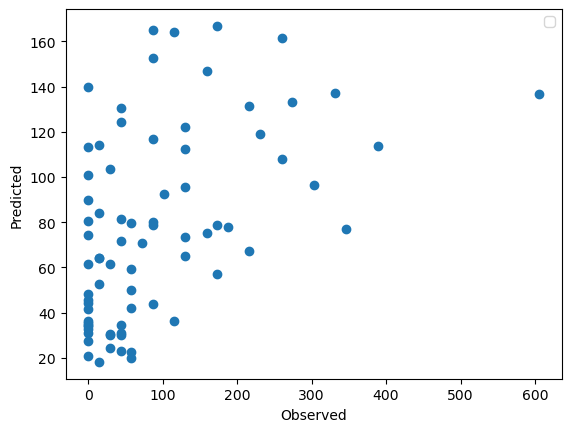

In [119]:
mse = np.mean((y_eval - y_pred) ** 2)
print(f"Mean Squared Error (MSE): {mse}")
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error (MAE): {mae:.3f}")
# Calculate R-squareds
ss_residual = np.sum((y_eval - y_pred) ** 2)  # Residual Sum of Squares
ss_total = np.sum((y_eval - np.mean(y_eval)) ** 2)  # Total Sum of Squares
r2 = 1 - (ss_residual / ss_total)
print(f"R-squared (R²): {r2}")

relative_error = np.abs((np.array(y_pred) - np.array(y_test))) / np.array(y_test)
# Check if within 10%
accurate = np.mean(relative_error <= 0.1)
print("Custom accuracy: ", accurate)
# print("relative error: ", np.mean(relative_error))
plt.scatter(y_test, y_pred)
plt.xlabel("Observed")
plt.ylabel("Predicted")
plt.legend()
plt.show()

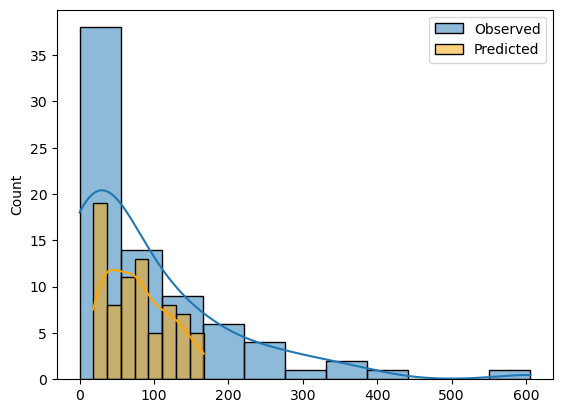

In [120]:
sns.histplot(y_test, kde=True, label="Observed")
sns.histplot(y_pred, kde=True, label="Predicted", color="orange")
plt.legend()
plt.show()

/home/julian/miniconda3/envs/pymc-bart/lib/python3.12/site-packages/arviz/plots/plot_utils.py:270: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of variables to plot (303) in plot_posterior, generating only 40 plots
  warnings.warn(


array([[<Axes: title={'center': 'μ\n0'}>,
        <Axes: title={'center': 'μ\n1'}>,
        <Axes: title={'center': 'μ\n2'}>,
        <Axes: title={'center': 'μ\n3'}>],
       [<Axes: title={'center': 'μ\n4'}>,
        <Axes: title={'center': 'μ\n5'}>,
        <Axes: title={'center': 'μ\n6'}>,
        <Axes: title={'center': 'μ\n7'}>],
       [<Axes: title={'center': 'μ\n8'}>,
        <Axes: title={'center': 'μ\n9'}>,
        <Axes: title={'center': 'μ\n10'}>,
        <Axes: title={'center': 'μ\n11'}>],
       [<Axes: title={'center': 'μ\n12'}>,
        <Axes: title={'center': 'μ\n13'}>,
        <Axes: title={'center': 'μ\n14'}>,
        <Axes: title={'center': 'μ\n15'}>],
       [<Axes: title={'center': 'μ\n16'}>,
        <Axes: title={'center': 'μ\n17'}>,
        <Axes: title={'center': 'μ\n18'}>,
        <Axes: title={'center': 'μ\n19'}>],
       [<Axes: title={'center': 'μ\n20'}>,
        <Axes: title={'center': 'μ\n21'}>,
        <Axes: title={'center': 'μ\n22'}>,
        <Axes: t

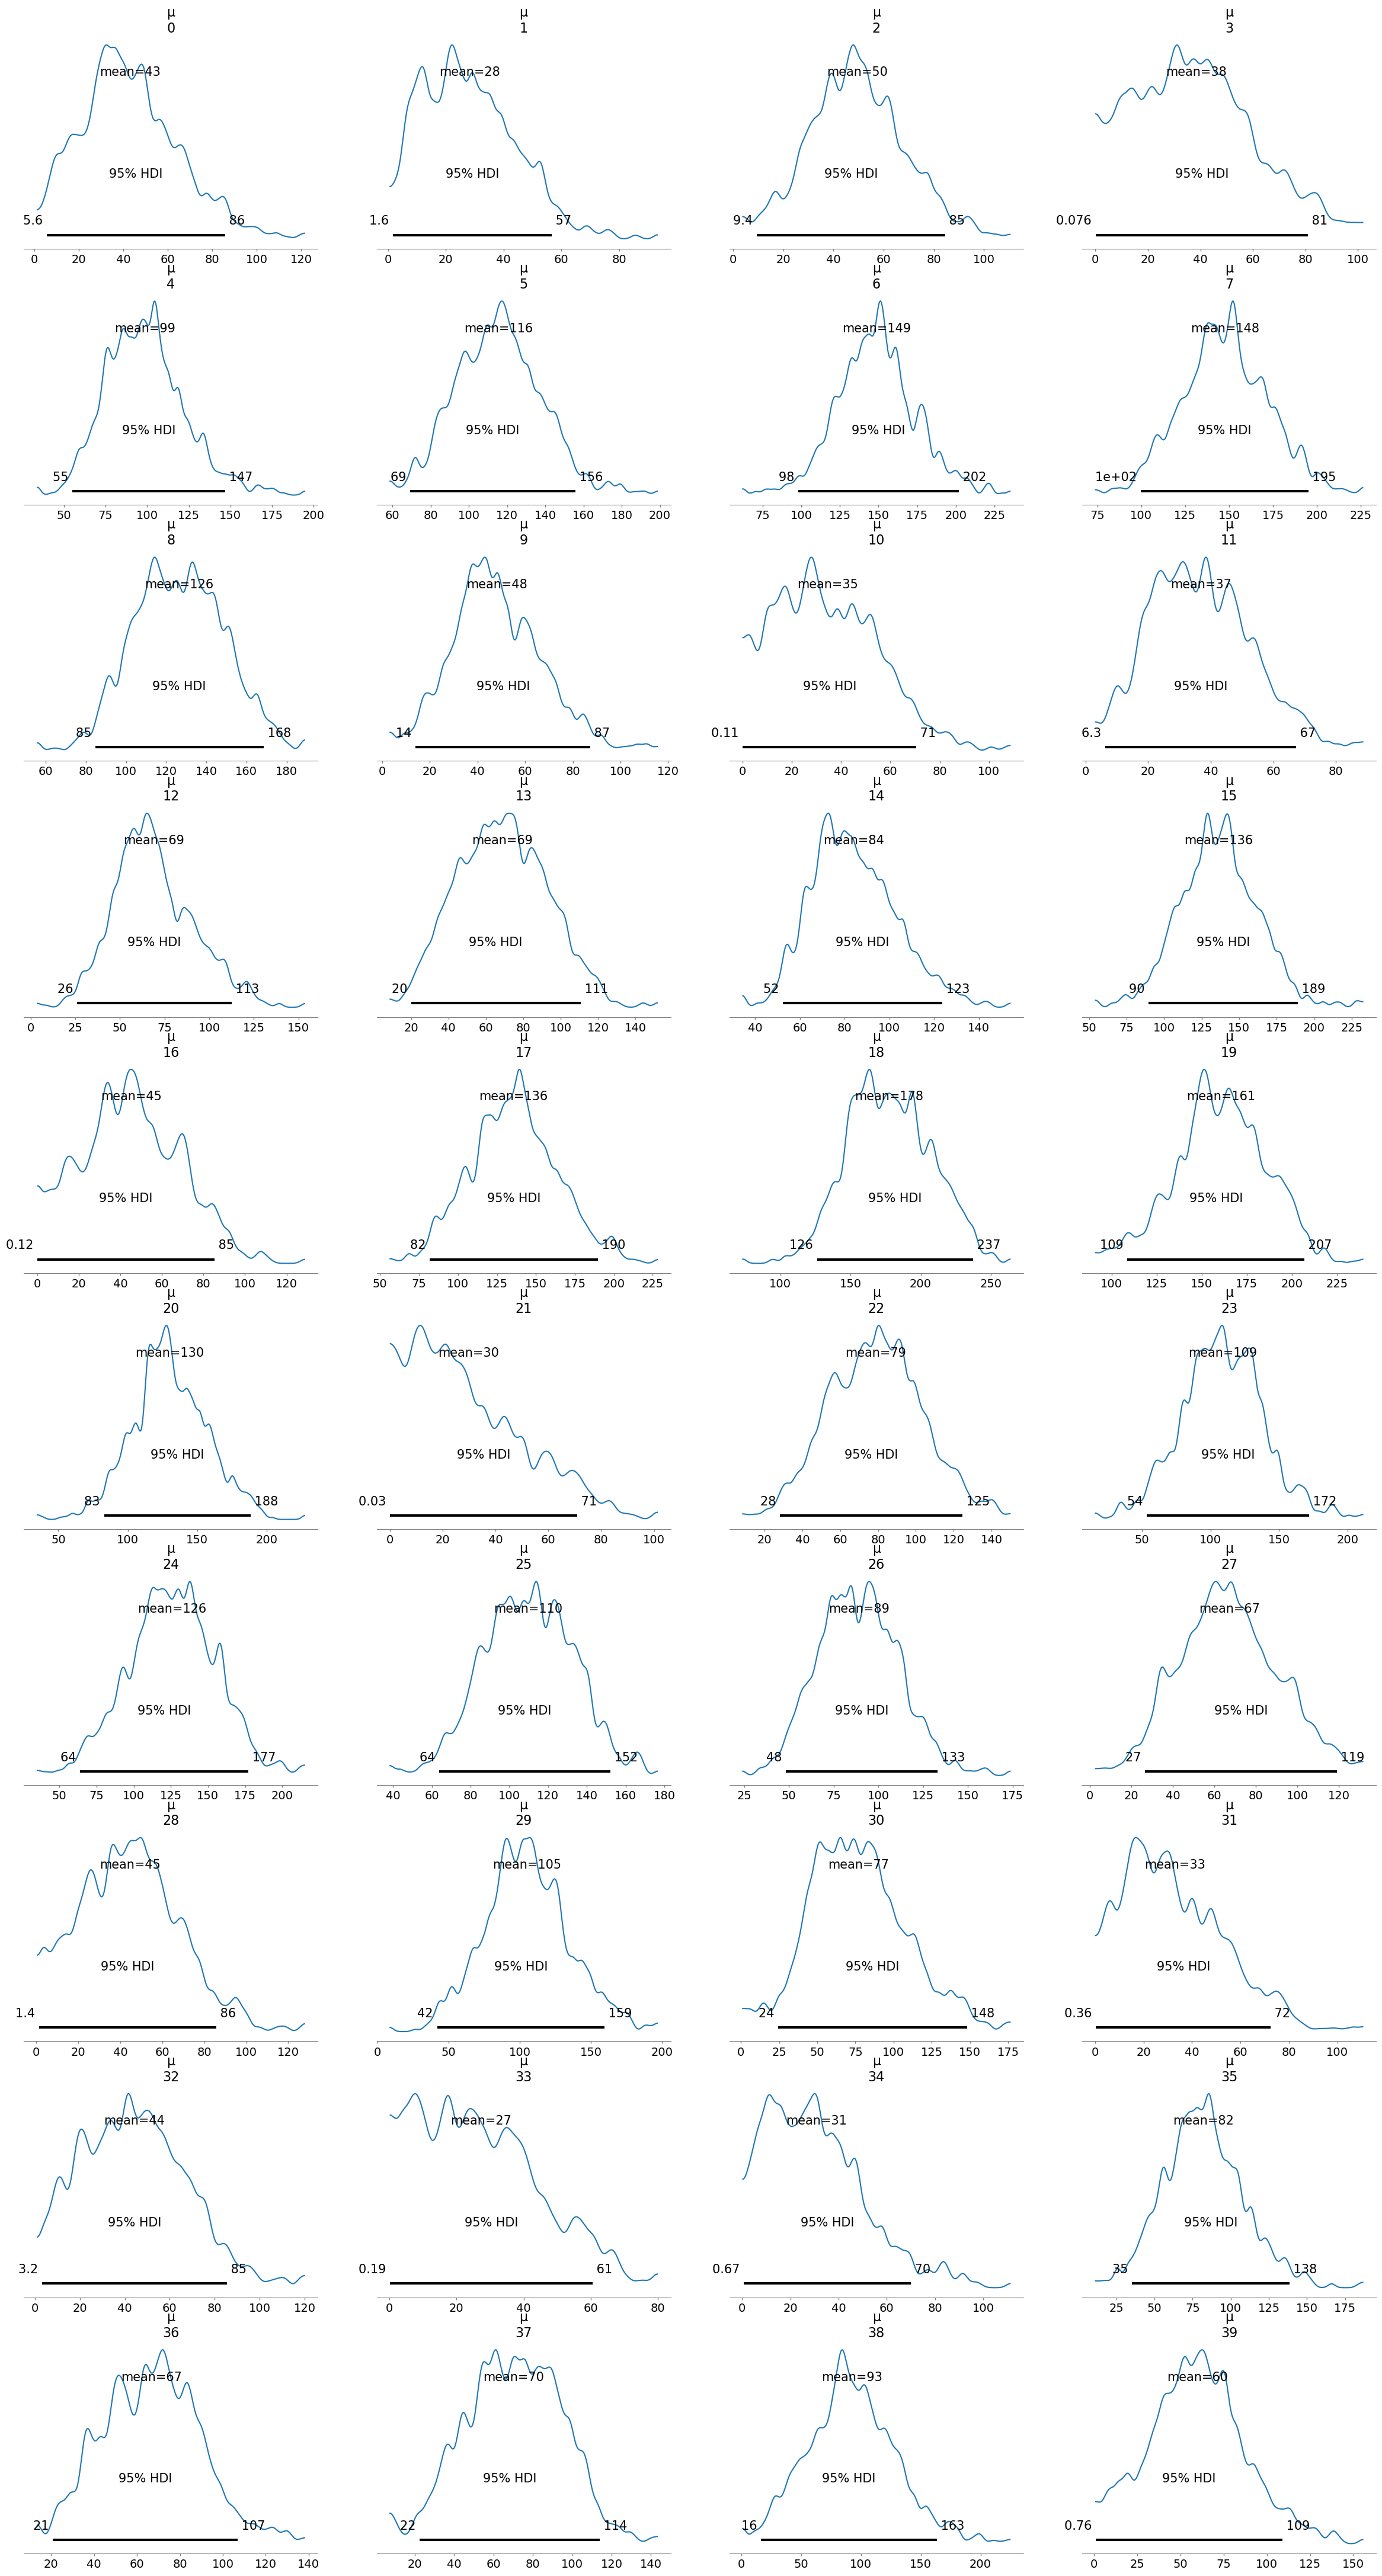

In [121]:
az.plot_posterior(trace, var_names=["μ"], kind="kde", hdi_prob=0.95)


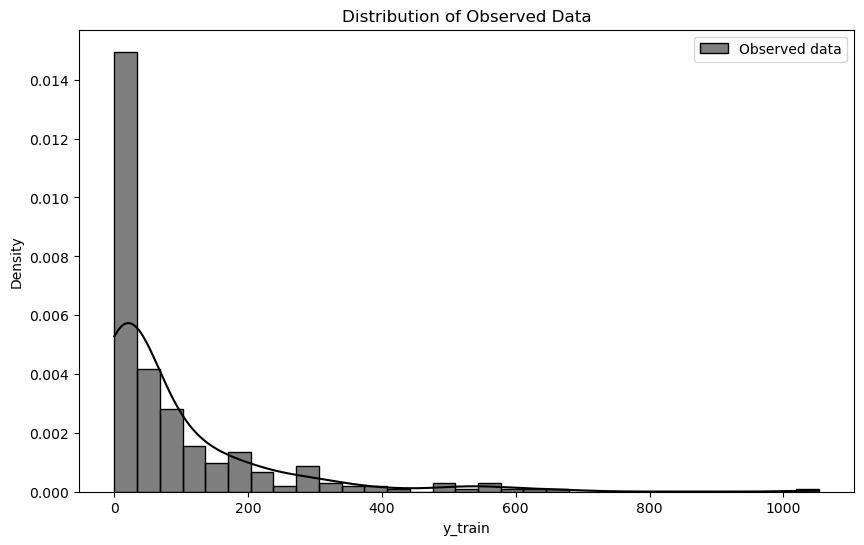

In [122]:
plt.figure(figsize=(10, 6))
sns.histplot(y_train, kde=True, stat="density", color='black', label='Observed data')
plt.title("Distribution of Observed Data")
plt.xlabel("y_train")
plt.ylabel("Density")
plt.legend()
plt.show()

Proportion of zeros: 0.0


([38,
  23,
  24,
  17,
  6,
  10,
  45,
  1,
  33,
  27,
  11,
  43,
  13,
  9,
  16,
  25,
  22,
  29,
  40,
  28,
  34,
  12,
  47,
  37,
  8,
  35,
  20,
  3,
  46,
  31,
  18,
  32,
  41,
  4,
  0,
  5,
  7,
  26,
  15,
  14,
  42,
  30,
  21,
  39,
  36,
  19,
  2,
  44],
 <Axes: ylabel='R²'>)

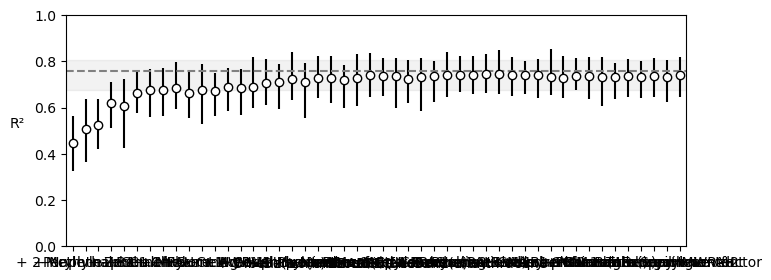

In [123]:
print("Proportion of zeros:", np.mean(p_test_pred.data<0.1))

pmb.plot_variable_importance(trace, μ_raw, X_train)

In [124]:
# def tweedie_logp(value, mu, p, phi):
#     # Ensure positive values for mu, p, and phi
#     est_lambda = mu ** (2 - p) / (2 - p)
#     est_alpha = (2 - p) / (p - 1)
#     est_beta = mu ** (1 - p) / (p - 1)
#     gam = phi * (p - 1 ) * (mu ** (p - 1 ))

#     #Calculate the log probability using the provided parameters and observed value
#     logp_value = (
#         (1 - p) * np.log(value.eval() / mu) - (value.eval() / (mu ** p * phi)) - np.log(phi)
#         + np.log((1 - p) * mu ** (1 - p)))


#     return logp_value

# def tweedie_random(mu, p, phi, rng=None, size=None):
#     # Generate random samples using the inverse CDF or other sampling method for Tweedie
#     # Note: This assumes you have a way to sample from the Tweedie distribution
#     # Here we use a simple approximation (you could replace it with a more accurate method)
    
#     # Sample from Poisson
#     poisson_part = np.random.poisson(mu**(2-p)/phi, size=size)
    
#     # Sample from Gamma
#     gamma_part = np.random.gamma(1/phi, scale=phi * mu, size=size)
    
#     # Combine components (e.g., zero inflation or compound distribution)
#     # This is a placeholder for the actual sampling mechanism
#     return poisson_part * gamma_part

# with pm.Model() as bart_g:
#     # Priors
#     p = pm.Beta("p", alpha=2, beta=2)       # Power parameter (1 < p < 2)
#     phi = pm.Gamma('phi', alpha=1, beta=1)

#     # Data
#     X = pm.Data("X", X_train)
#     y = pm.Data("y", y_train+0.0000001)
    
#     # BART for non-zero values
#     μ_raw = pmb.BART("μ_raw", X, y_train, m=80)
    
#     # Tweedie likelihood
#     y_obs = pm.CustomDist('y_obs', μ_raw, p, phi, logp=tweedie_logp, random=tweedie_random, observed=y)

# pm.model_to_graphviz(bart_g)

/home/julian/miniconda3/envs/pymc-bart/lib/python3.12/site-packages/arviz/plots/plot_utils.py:270: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of variables to plot (607) in plot_posterior, generating only 40 plots
  warnings.warn(


array([[<Axes: title={'center': 'μ_raw\n0'}>,
        <Axes: title={'center': 'μ_raw\n1'}>,
        <Axes: title={'center': 'μ_raw\n2'}>,
        <Axes: title={'center': 'μ_raw\n3'}>],
       [<Axes: title={'center': 'μ_raw\n4'}>,
        <Axes: title={'center': 'μ_raw\n5'}>,
        <Axes: title={'center': 'μ_raw\n6'}>,
        <Axes: title={'center': 'μ_raw\n7'}>],
       [<Axes: title={'center': 'μ_raw\n8'}>,
        <Axes: title={'center': 'μ_raw\n9'}>,
        <Axes: title={'center': 'μ_raw\n10'}>,
        <Axes: title={'center': 'μ_raw\n11'}>],
       [<Axes: title={'center': 'μ_raw\n12'}>,
        <Axes: title={'center': 'μ_raw\n13'}>,
        <Axes: title={'center': 'μ_raw\n14'}>,
        <Axes: title={'center': 'μ_raw\n15'}>],
       [<Axes: title={'center': 'μ_raw\n16'}>,
        <Axes: title={'center': 'μ_raw\n17'}>,
        <Axes: title={'center': 'μ_raw\n18'}>,
        <Axes: title={'center': 'μ_raw\n19'}>],
       [<Axes: title={'center': 'μ_raw\n20'}>,
        <Axes: tit

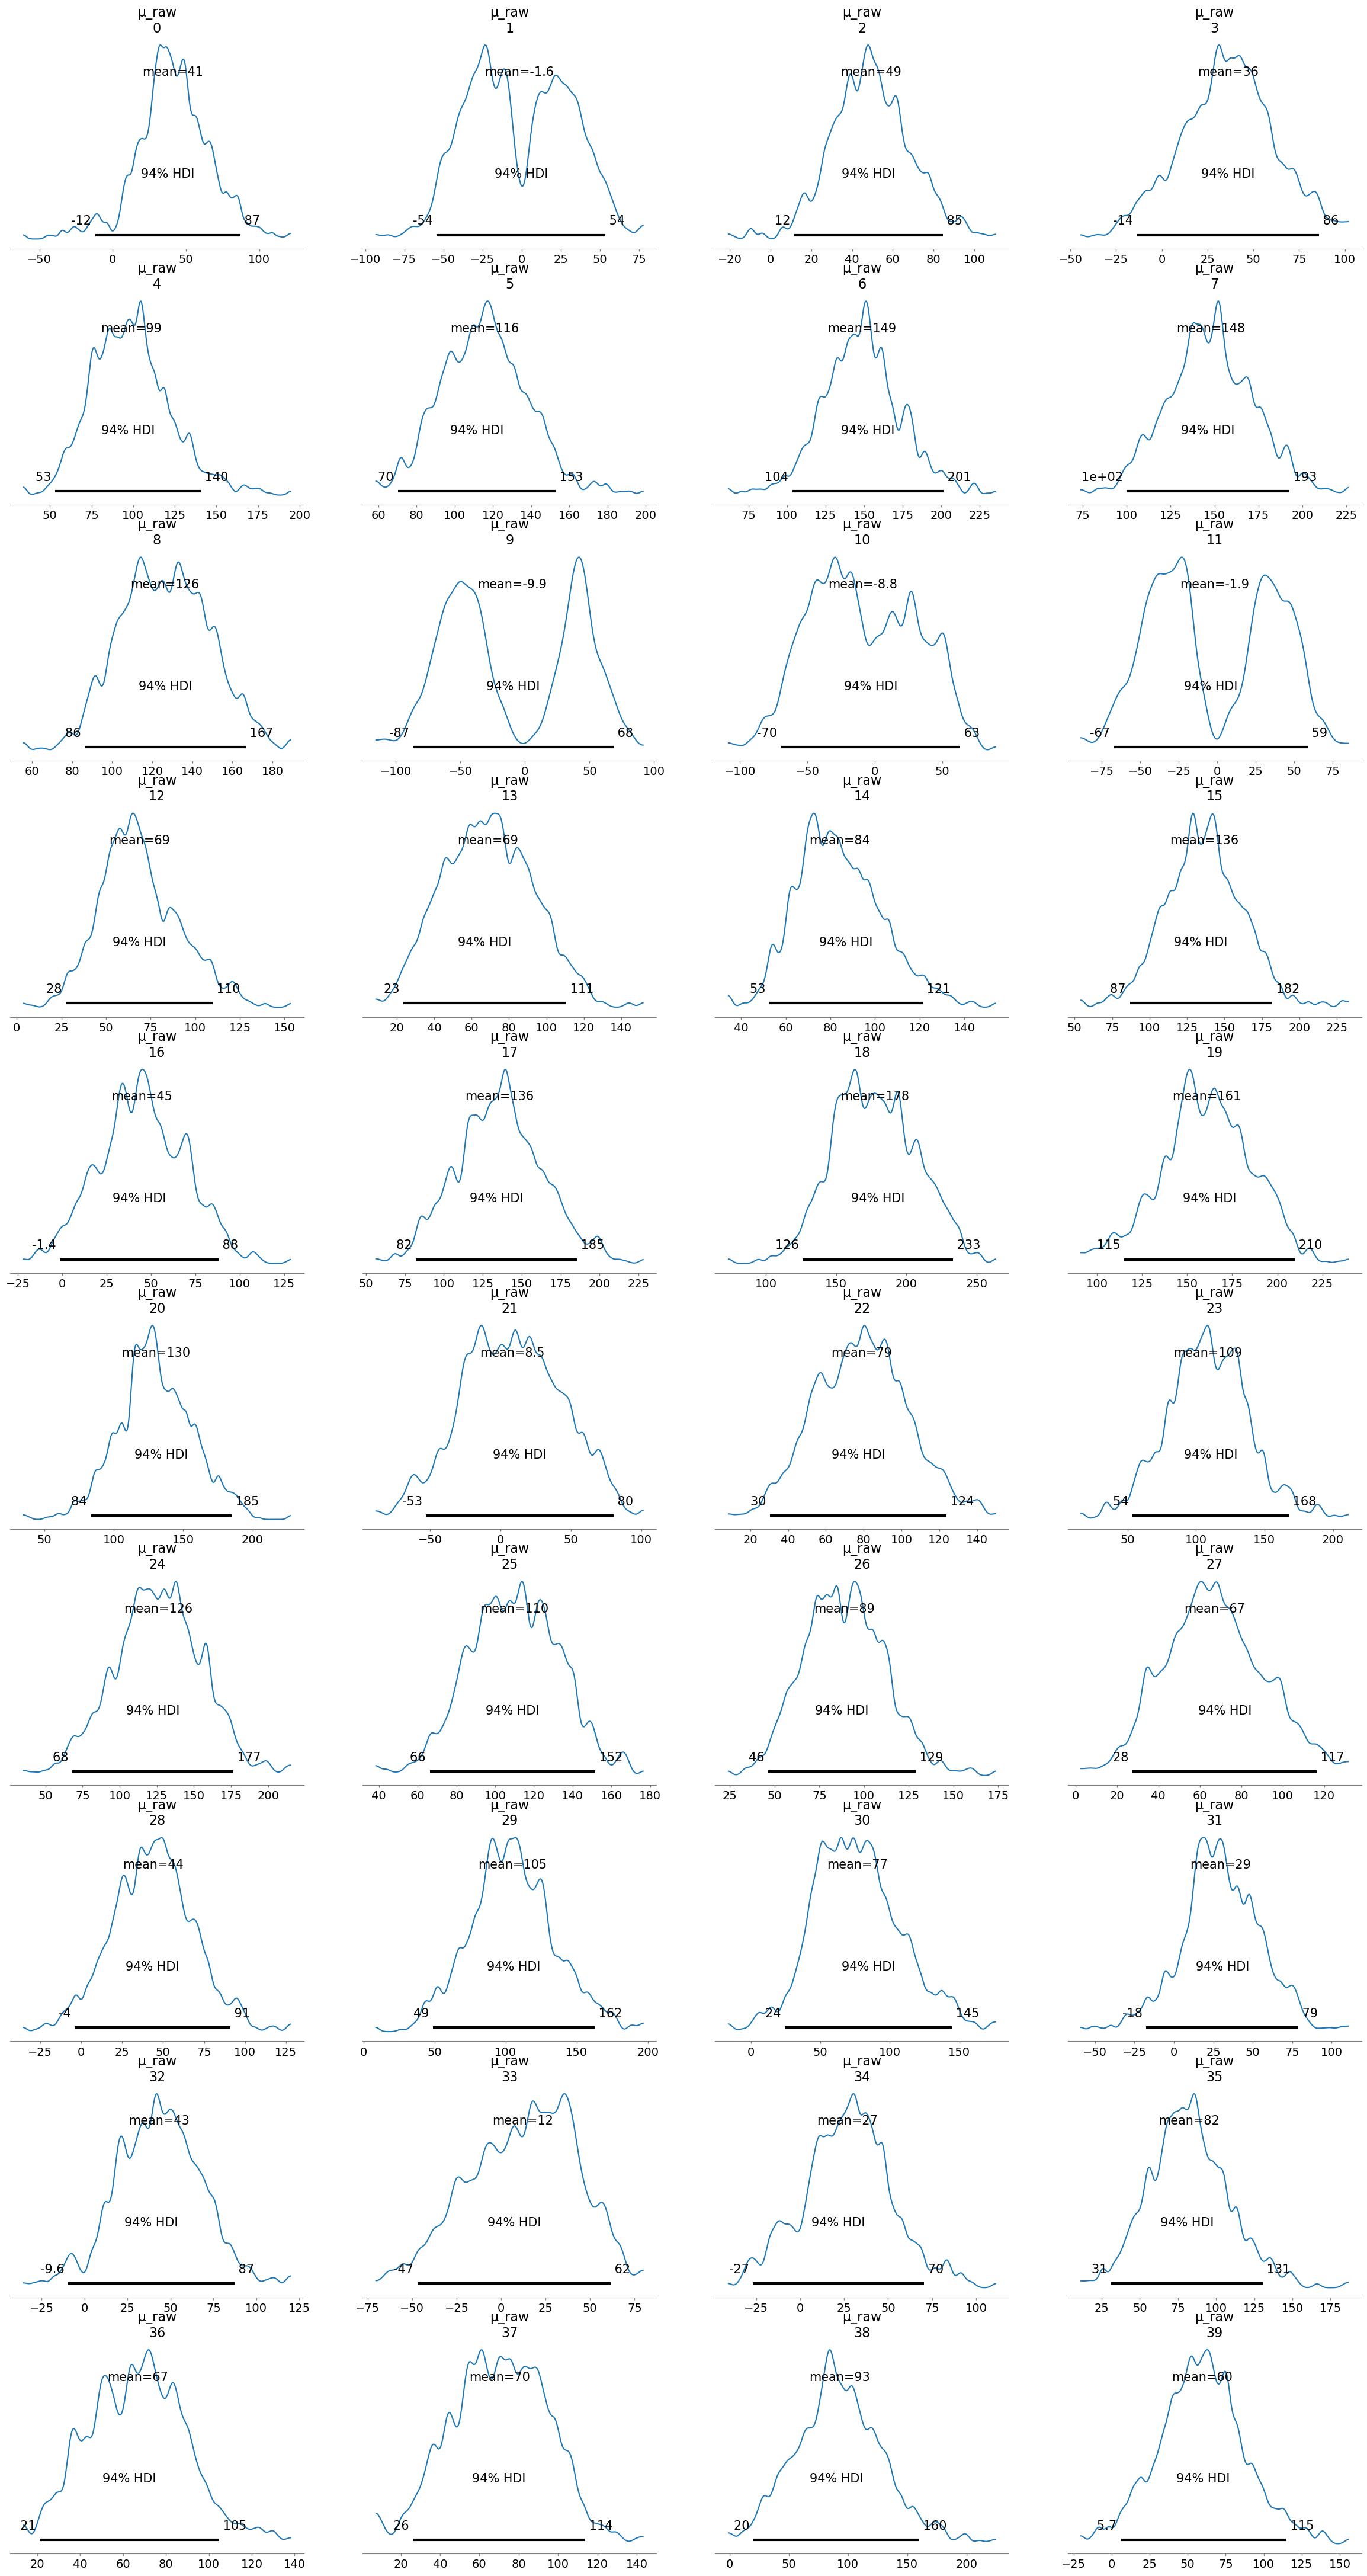

In [125]:
az.summary(trace,)
az.plot_posterior(trace)

In [126]:
# az.plot_posterior(trace)
trace

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data
	> constant_data

array([[<Axes: title={'center': 'y_obs'}>,
        <Axes: title={'center': 'y_obs'}>]], dtype=object)

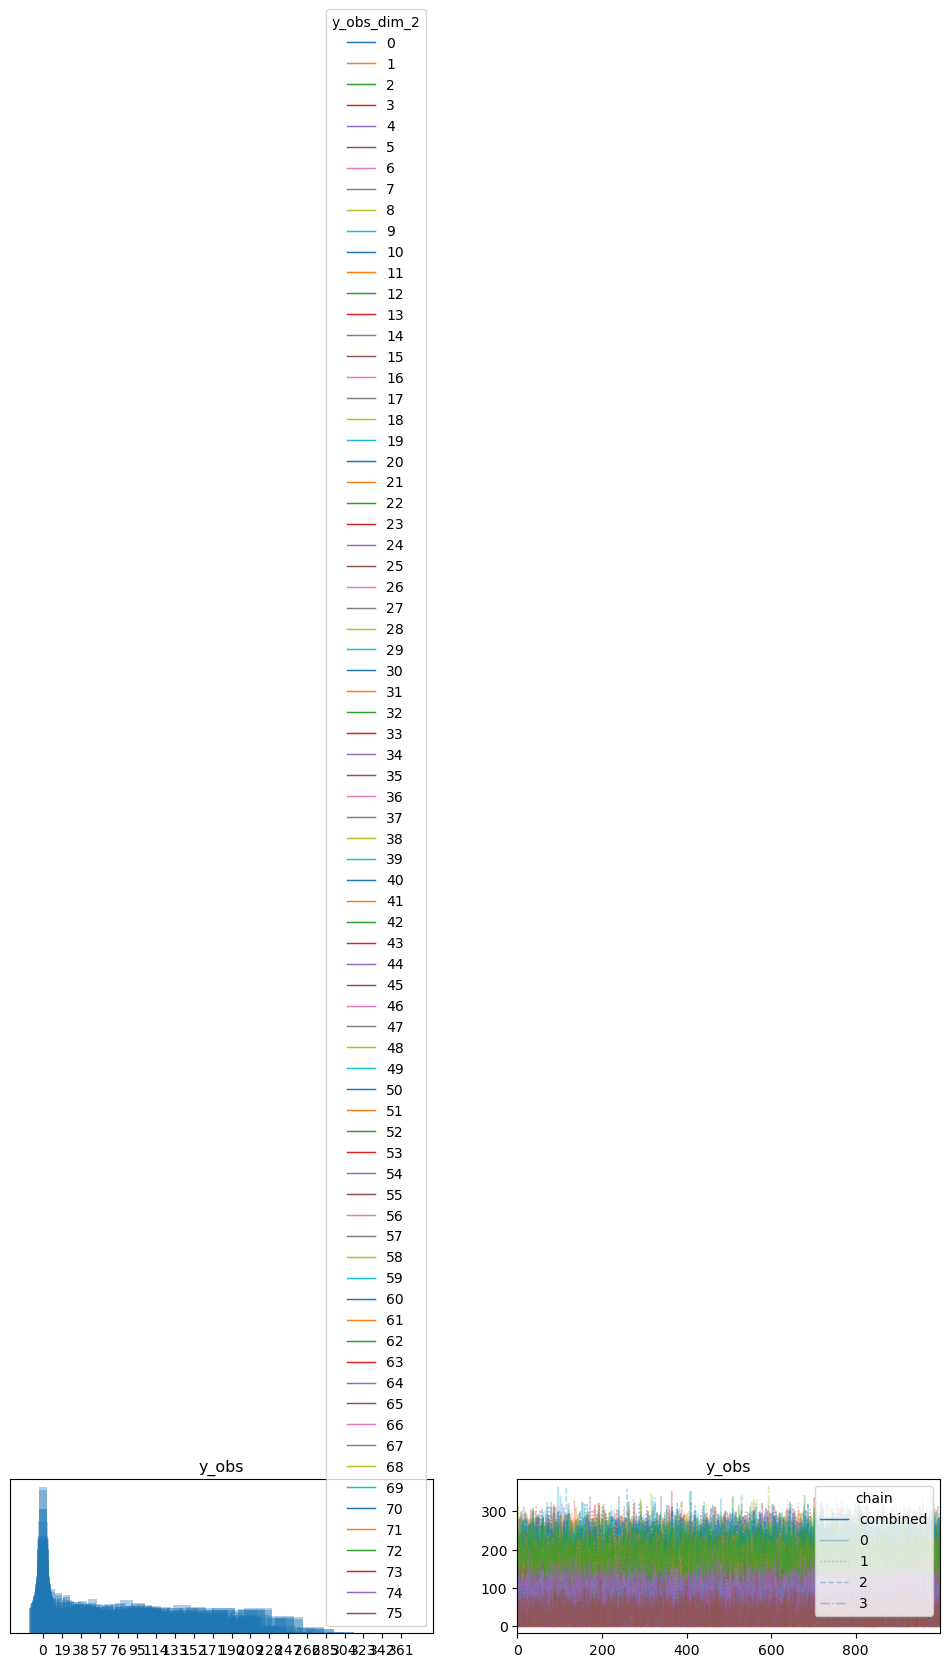

In [127]:
az.plot_trace(pp.predictions, var_names="y_obs", compact=True, combined=True, legend = True)